#GAURAV KUMAR
#2501940033
#Deep Learning Architectures and Techniques (ETMMDL274)
---------------------------------------------------------------------------------------------
# **ASSIGNMENT - 2**
##**Multiclass Image Classification Using Convolutional Neural Networks and Transfer Learning**
This laboratory assignment introduces students to Convolutional Neural Networks (CNNs) for
image classification. Students will design a basic CNN and then apply transfer learning using
a pretrained model to perform multiclass object recognition, reinforcing core Unit II concepts
such as convolution, pooling, data augmentation, and evaluation metrics.


1. Import libraries

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import confusion_matrix, classification_report

2. Load Dataset

In [7]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print(X_train.shape)

(60000, 28, 28)


3. Preprocessing


In [8]:
#Normalization
X_train = X_train / 255.0
X_test = X_test / 255.0

#Reshape for CNN
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

#One-hot encoding
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

4. Data Augmentation

In [9]:
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

datagen.fit(X_train)

5. Custom CNN Model

In [10]:
cnn_model = Sequential()

cnn_model.add(Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)))
cnn_model.add(MaxPooling2D((2,2)))

cnn_model.add(Conv2D(64,(3,3),activation='relu'))
cnn_model.add(MaxPooling2D((2,2)))

cnn_model.add(Flatten())

cnn_model.add(Dense(128,activation='relu'))
cnn_model.add(Dropout(0.5))

cnn_model.add(Dense(10,activation='softmax'))

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train CNN
history_cnn = cnn_model.fit(
    datagen.flow(X_train,y_train,batch_size=64),
    epochs=10,
    validation_data=(X_test,y_test)
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


938/938 ━━━━━━━━━━━━━━━━━━━━ 76s 78ms/step - accuracy: 0.6158 - loss: 1.0498 - val_accuracy: 0.8040 - val_loss: 0.5143
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 69s 74ms/step - accuracy: 0.7661 - loss: 0.6172 - val_accuracy: 0.8288 - val_loss: 0.4578
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 70s 75ms/step - accuracy: 0.7972 - loss: 0.5446 - val_accuracy: 0.8559 - val_loss: 0.3886
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 69s 74ms/step - accuracy: 0.8127 - loss: 0.5009 - val_accuracy: 0.8614 - val_loss: 0.3754
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 70s 75ms/step - accuracy: 0.8265 - loss: 0.4645 - val_accuracy: 0.8658 - val_loss: 0.3544
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 70s 75ms/step - accuracy: 0.8327 - loss: 0.4501 - val_accuracy: 0.8755 - val_loss: 0.3358
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 70s 74ms/step - accuracy: 0.8437 - loss: 0.4258 - val_accuracy: 0.8745 - val_loss: 0.3343
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 76s 80ms/step - accuracy: 0.8467 - loss: 0.4172 - val_accurac

6. Plot Training Curves

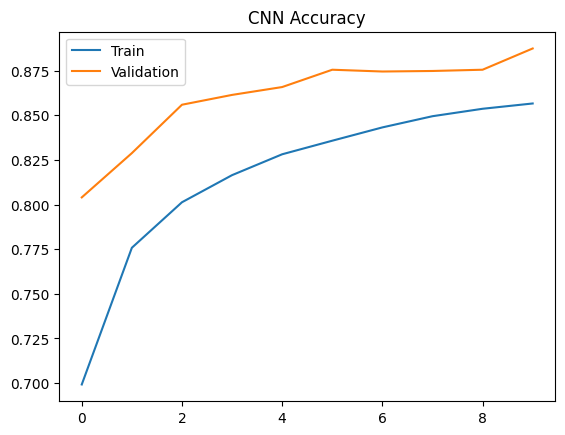

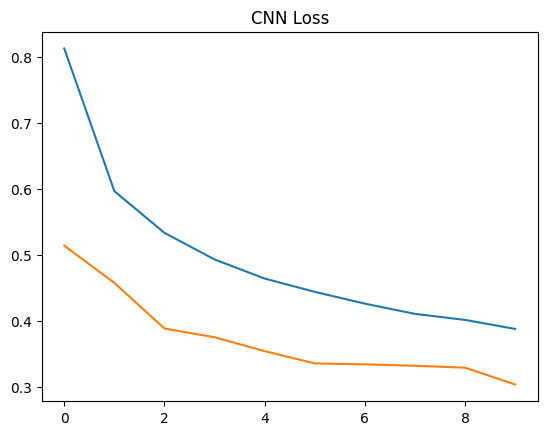

In [11]:
import os

# Create the 'plots' directory if it doesn't exist
os.makedirs('plots', exist_ok=True)

# Accuracy
plt.plot(history_cnn.history['accuracy'])
plt.plot(history_cnn.history['val_accuracy'])

plt.title("CNN Accuracy")
plt.legend(["Train","Validation"])

plt.savefig("plots/cnn_accuracy.png")
plt.show()

# Loss
plt.plot(history_cnn.history['loss'])
plt.plot(history_cnn.history['val_loss'])

plt.title("CNN Loss")

plt.savefig("plots/cnn_loss.png")
plt.show()

7. Transfer Learning Model

In [12]:
# Using MobileNetV2
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

# Resize images
import tensorflow as tf

X_train_resized = tf.image.resize(X_train,(96,96))
X_test_resized = tf.image.resize(X_test,(96,96))

# Load Pretrained Model
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(96,96,3)
)

# Freeze layers:
for layer in base_model.layers:
    layer.trainable=False

7. (a) Build Model

In [13]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128,activation='relu')(x)
predictions = Dense(10,activation='softmax')(x)

model_transfer = Model(inputs=base_model.input, outputs=predictions)

model_transfer.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

7. (b) Train Model

In [14]:
import tensorflow as tf

# Resize images for MobileNetV2
X_train_resized = tf.image.resize(X_train, (96,96))
X_test_resized = tf.image.resize(X_test, (96,96))

# Ensure the last dimension is 1 (grayscale) before converting to RGB
if len(X_train_resized.shape) == 3:
    X_train_resized = tf.expand_dims(X_train_resized, axis=-1)
if len(X_test_resized.shape) == 3:
    X_test_resized = tf.expand_dims(X_test_resized, axis=-1)

# Replicate the single channel to three channels for the MobileNetV2 input
X_train_resized_rgb = tf.image.grayscale_to_rgb(X_train_resized)
X_test_resized_rgb = tf.image.grayscale_to_rgb(X_test_resized)

# Explicitly build the model to avoid ValueError during tf.function tracing
_ = model_transfer(X_train_resized_rgb[:1])

history_transfer = model_transfer.fit(
    X_train_resized_rgb,
    y_train,
    epochs=5,
    validation_data=(X_test_resized_rgb,y_test)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 456s 237ms/step - accuracy: 0.8401 - loss: 0.4474 - val_accuracy: 0.8827 - val_loss: 0.3060
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 449s 240ms/step - accuracy: 0.8970 - loss: 0.2727 - val_accuracy: 0.8861 - val_loss: 0.3153
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 420s 224ms/step - accuracy: 0.9101 - loss: 0.2407 - val_accuracy: 0.8913 - val_loss: 0.2973
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 423s 225ms/step - accuracy: 0.9190 - loss: 0.2119 - val_accuracy: 0.8953 - val_loss: 0.2928
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 433s 231ms/step - accuracy: 0.9268 - loss: 0.1925 - val_accuracy: 0.8963 - val_loss: 0.2949


8. Evaluation

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


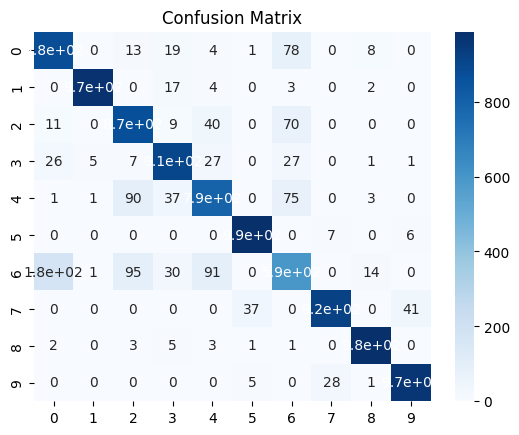

              precision    recall  f1-score   support

           0       0.80      0.88      0.84      1000
           1       0.99      0.97      0.98      1000
           2       0.81      0.87      0.84      1000
           3       0.89      0.91      0.90      1000
           4       0.82      0.79      0.81      1000
           5       0.96      0.99      0.97      1000
           6       0.70      0.59      0.64      1000
           7       0.96      0.92      0.94      1000
           8       0.97      0.98      0.98      1000
           9       0.95      0.97      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [15]:
# Predictions:
y_pred = cnn_model.predict(X_test)
y_pred = np.argmax(y_pred,axis=1)

y_true = np.argmax(y_test,axis=1)


# Confusion Matrix
cm = confusion_matrix(y_true,y_pred)

sns.heatmap(cm,annot=True,cmap="Blues")

plt.title("Confusion Matrix")

plt.savefig("plots/confusion_matrix.png")
plt.show()

# Classification Report
print(classification_report(y_true,y_pred))